## 분류와 군집화

### 로지스틱 회귀 모델과 시그모이드 함수

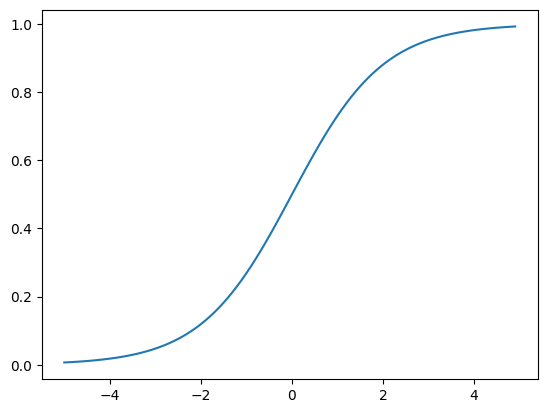

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
   return 1.0/(1.0 + np.exp(-x))

x = np.arange(-5., 5., 0.1)
plt.plot(x, sigmoid(x))

**시그모이드 함수와 지수의 관계**

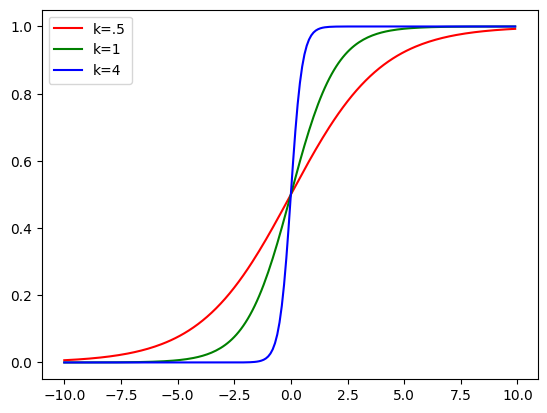

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x, k):
   return 1.0/(1.0 + np.exp(-x*k))

x = np.arange(-10., 10., 0.1)
plt.plot(x, sigmoid(x, .5), 'r', label='k=.5')
plt.plot(x, sigmoid(x, 1), 'g', label='k=1')
plt.plot(x, sigmoid(x, 4), 'b', label='k=4')
plt.legend()

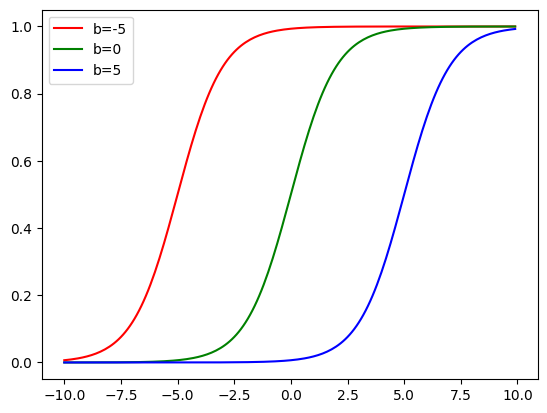

In [3]:
def sigmoid(x, b):
  return 1.0/(1.0 + np.exp(-x + b))

x = np.arange(-10., 10., 0.1)
plt.plot(x, sigmoid(x, b=-5), 'r', label='b=-5')
plt.plot(x, sigmoid(x, b=0), 'g', label='b=0')
plt.plot(x, sigmoid(x, b=5), 'b', label='b=5')
plt.legend()

## 결정 경계와 교차 엔트로피(비용함수)

### 로지스틱 회귀 모델을 위한 데이터 만들기

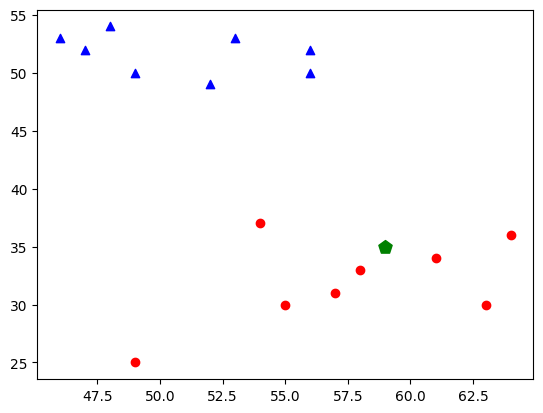

In [6]:
import matplotlib.pyplot as plt

# 닥스훈트의 길이와 높이 데이터
dach_length = [55, 57, 64, 63, 58, 49, 54, 61]
dach_height = [30, 31, 36, 30, 33, 25, 37, 34]
# 진돗개의 길이와 높이 데이터
jin_length = [56, 47, 56, 46, 49, 53, 52, 48]
jin_height = [52, 52, 50, 53, 50, 53, 49, 54]

#모르는 데이타. 테스트 데이타
newdata_length = [59]    # 새로운 데이터의 길이
newdata_height = [35]    # 새로운 데이터의 높이

plt.scatter(dach_length, dach_height, c='r', label='Dachshund')
plt.scatter(jin_length, jin_height,c='b',marker='^', label='Jindo dog')
# 새 데이터의 표식은 오각형(pentagon)으로 설정하고, 레이블은 new Data로
plt.scatter(newdata_length, newdata_height, s=100, marker='p', c='g', label='new Data')

#plt.xlabel('Length')
#plt.ylabel('Height')
#plt.title("Dog size")
#plt.legend(loc='upper right')

**데이타 생성 단계1**

In [9]:
import numpy as np

d_data = np.column_stack((dach_length, dach_height))
d_label = np.zeros(len(d_data))   # 닥스훈트는 0으로 레이블링

j_data = np.column_stack((jin_length, jin_height))
j_label = np.ones(len(j_data))   # 진돗개는 1로 레이블링

print(d_data), print(d_label)

[[55 30]
 [57 31]
 [64 36]
 [63 30]
 [58 33]
 [49 25]
 [54 37]
 [61 34]]
[0. 0. 0. 0. 0. 0. 0. 0.]


(None, None)

**데이타 생성 단계2**

In [ ]:
dogs = np.concatenate((d_data, j_data))
labels = np.concatenate((d_label, j_label))
print(dogs, labels)
dog_classes = {0:'닥스훈트', 1:'진돗개'}
newdata = [[59, 35]] #unknown dog


[[55 30]
 [57 31]
 [64 36]
 [63 30]
 [58 33]
 [49 25]
 [54 37]
 [61 34]
 [56 52]
 [47 52]
 [56 50]
 [46 53]
 [49 50]
 [53 53]
 [52 49]
 [48 54]] [0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1.]


**회귀 모델 구현**

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

f = LogisticRegression() #분류
f.fit(dogs, labels)
w = f.coef_[0] # 계수. 이건 형태를 파악 후 구해야 할 것 같다.
b = f.intercept_[0] # 절편. 이것도 형태를 파악 후 구해야 할 것 같다.
print('계수:', w)
print('절편:', b)
print('분류 정확도:', f.score(dogs, labels))

y_pred = f.predict(newdata) #predict 함수는 배열 형태로 리턴
y_pred_prob = f.predict_proba(newdata) #predict_proba 함수는 배열 형태로 리턴
print(f'데이터: {newdata}')
print(f'판정 결과: {dog_classes[y_pred[0]]}, 판정 확률: {y_pred_prob}')

계수: [-0.12467735  0.60518946]
절편: -19.029836138332463
분류 정확도: 1.0
데이터: [[59, 35]]
판정 결과: 닥스훈트, 판정 확률: [[0.9945364 0.0054636]]


**결정 경계에서 w0*x0 + w1*x1 + b = 0 이므로 => x1 = -w0/w1 * x0 - b/w1**


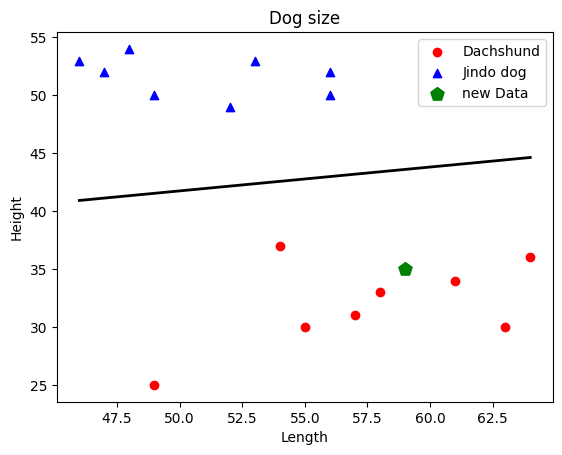

In [12]:
plt.scatter(dach_length, dach_height, c='r', label='Dachshund')
plt.scatter(jin_length, jin_height,c='b',marker='^', label='Jindo dog')
# 새 데이터의 표식은 오각형(pentagon)으로 설정하고, 레이블은 new Data로
plt.scatter(newdata_length, newdata_height, s=100, marker='p', c='g', label='new Data')

plt.xlabel('Length')
plt.ylabel('Height')
plt.title("Dog size")
plt.legend(loc='upper right')

x0 = np.linspace(np.min([dach_length, jin_length]),\
                 np.max([dach_length, jin_length]), 200)
decision_boundary = -w[0]/w[1] * x0 - b/w[1]
# 결정 경계에서 w0*x0 + w1*x1 + b = 0 이므로 => x1 = -w0/w1 * x0 - b/w1
plt.plot(x0, decision_boundary, "k-", linewidth=2)
plt.show()

**직접 분할하면서 만들기**

In [13]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(3)
knn.fit(dogs, labels)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [14]:
y_pred = knn.predict(newdata)
print('데이터', newdata, ', 판정 결과:', dog_classes[y_pred[0]])

데이터 [[59, 35]] , 판정 결과: 닥스훈트


In [18]:
from sklearn.datasets import load_iris

iris = load_iris()
iris.data[:3]     # 최초 3개 데이터의 값을 출력
print(iris.DESCR)


.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [19]:
print(len(iris.data))

150


In [20]:
print(iris.target)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [21]:
print(iris.target.sum())

150


In [22]:
import pandas as pd

iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['target'] = pd.Series(iris.target)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [23]:
iris_df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [24]:
X=iris_df.iloc[:, :4] #입력 데이타
y=iris_df.iloc[:,-1] #target

**훈련**

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.3)
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [44]:
y_pred = knn.predict(X_test)

print(y_pred,'\n', y_test)
### 여기 문제가 있음
from sklearn import metrics
metrics.accuracy_score(y_test, y_pred)
#knn.score(y_test, y_pred) 이건 타입이 안 맞음. 공부할 필요 없는것 같음.

[0 0 2 1 0 1 1 0 2 2 0 2 1 2 1 2 1 1 1 0 2 2 2 0 1 0 2 2 0 1 2 0 2 0 0 2 1
 2 2 1 2 1 2 1 2] 
 12     0
26     0
105    2
76     1
9      0
93     1
78     1
24     0
70     1
135    2
10     0
100    2
92     1
139    2
106    2
112    2
57     1
61     1
97     1
31     0
128    2
68     1
132    2
34     0
87     1
1      0
136    2
72     1
35     0
79     1
115    2
38     0
144    2
23     0
41     0
116    2
73     1
120    2
124    2
91     1
114    2
82     1
126    2
64     1
145    2
Name: target, dtype: int64


0.9111111111111111

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

def iris_knn(X, y, k):
    X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.3)
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    return metrics.accuracy_score(y_test, y_pred)

k = 3
scores = iris_knn(X, y, k)
print('n_neighbors가 {0:d}일때 정확도: {1:.3f}'.format(k, scores))

### 새로운 꽃에 대해서 모델을 적용하고 분류하는 방법

In [45]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier

k = 3
iris = load_iris()
knn = KNeighborsClassifier(n_neighbors = k)
knn.fit(iris.data, iris.target)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [46]:
classes = {0:'setosa', 1:'versicolor', 2:'virginica'}

# 새로운 데이터를 제시해 보자.
X = [[4, 2, 1.3, 0.4],
     [4, 3, 3.2, 2.2]]
y = knn.predict(X)

print('{} 특성을 가지는 품종: {}'.format(X[0], classes[y[0]]))
print('{} 특성을 가지는 품종: {}'.format(X[1], classes[y[1]]))

[4, 2, 1.3, 0.4] 특성을 가지는 품종: setosa
[4, 3, 3.2, 2.2] 특성을 가지는 품종: versicolor


In [47]:
y_pred_all = knn.predict(iris.data)
scores = metrics.accuracy_score(iris.target, y_pred_all)
print('n_neighbors가 {0:d}일때 정확도: {1:.3f}'.format(k, scores))

n_neighbors가 3일때 정확도: 0.960


(array([[50.,  0.,  0.],
        [ 0., 47.,  3.],
        [ 0.,  3., 47.]]),
 array([0.        , 0.66666667, 1.33333333, 2.        ]),
 array([0.        , 0.66666667, 1.33333333, 2.        ]),
 <matplotlib.collections.QuadMesh at 0x7cac1bf28f20>)

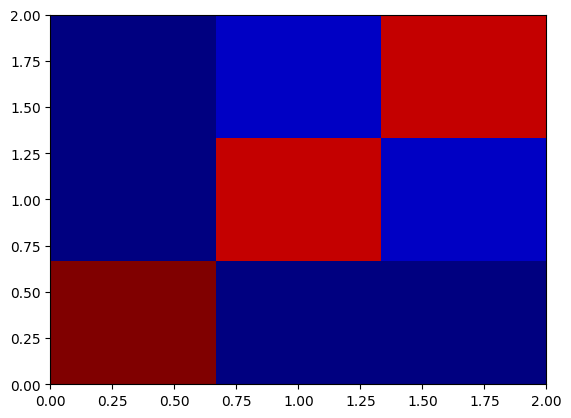

In [48]:
import matplotlib.pyplot as plt
plt.hist2d(iris.target, y_pred_all, bins=(3,3), cmap=plt.cm.jet)

(array([[50.,  0.,  0.],
        [ 0., 47.,  3.],
        [ 0.,  3., 47.]]),
 array([0.        , 0.66666667, 1.33333333, 2.        ]),
 array([0.        , 0.66666667, 1.33333333, 2.        ]),
 <matplotlib.collections.QuadMesh at 0x7cabeaada510>)

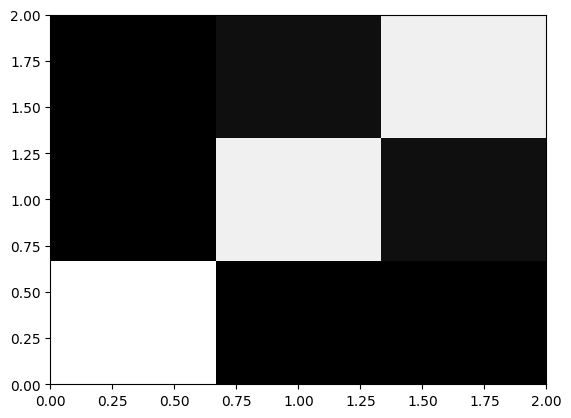

In [49]:
import matplotlib.pyplot as plt
plt.hist2d(iris.target, y_pred_all, bins=(3,3), cmap=plt.cm.gray)

In [50]:
from sklearn.metrics import confusion_matrix
conf_result = confusion_matrix(iris.target,y_pred_all)
print(np.flip(conf_result, axis=0))

[[ 0  3 47]
 [ 0 47  3]
 [50  0  0]]


## 게임하는 고객의 군집 분석

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


game_usage = pd.read_csv('./game_usage.csv')
game_usage.head(3)



,time spent,game level
0,39,944
1,55,705
2,29,757


### 데이타 전처리의 필요성

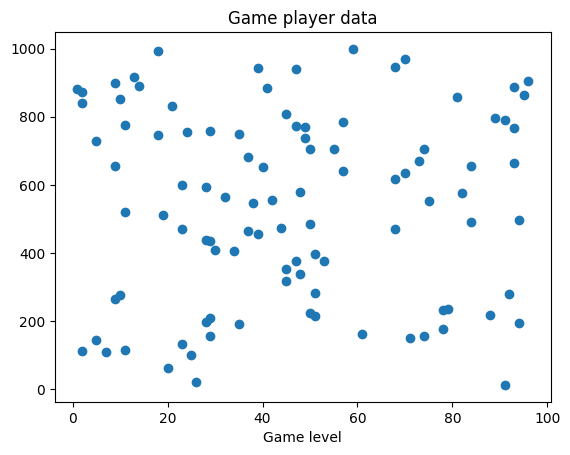

In [55]:
X = game_usage['time spent']
Y = game_usage['game level']

# 으뜸 게임사의 게임 이용자 분석: 산포도 그래프
plt.title("Game player data")
plt.xlabel('Time spent')
plt.xlabel('Game level')
plt.scatter(X, Y)

**위에서 보면 스케일이 잘못되어 있다. 가로가 100이고 세로가 1000이라 10개 차이가 나고 있다.**

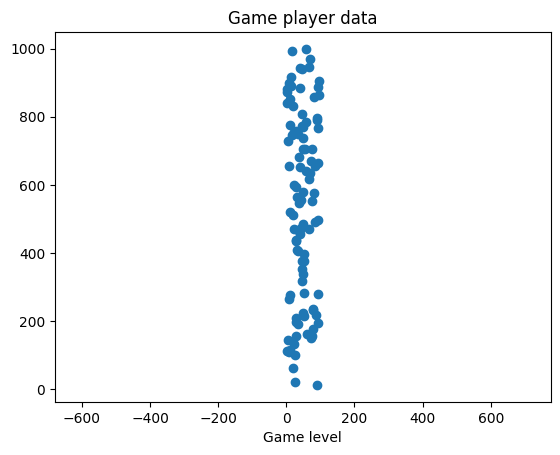

In [56]:
X = game_usage['time spent']
Y = game_usage['game level']

# 으뜸 게임사의 게임 이용자 분석: 산포도 그래프
plt.title("Game player data")
plt.xlabel('Time spent')
plt.xlabel('Game level')
plt.axis('equal') # 이렇케 만들었다.
plt.scatter(X, Y)

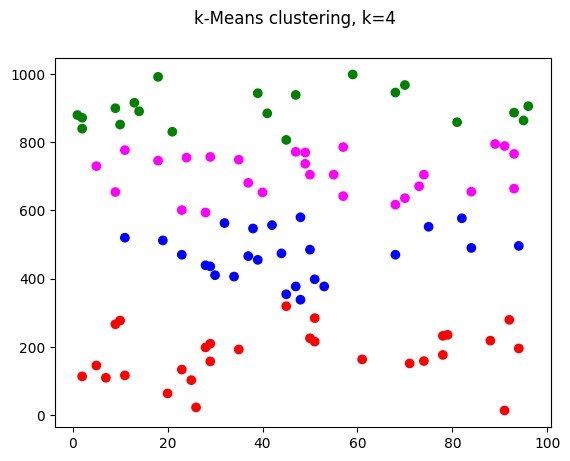

In [60]:
# k = 4일때의 결과
from sklearn import cluster

data = np.column_stack((X, Y))
K=4
model = cluster.KMeans(n_clusters=K, n_init=10)
model.fit(data)
labels = model.predict(data)
colors = np.array(['red', 'green', 'blue', 'magenta'])
plt.suptitle('k-Means clustering, k={}'.format(K))
plt.scatter(data[:, 0], data[:, 1], color=colors[labels])

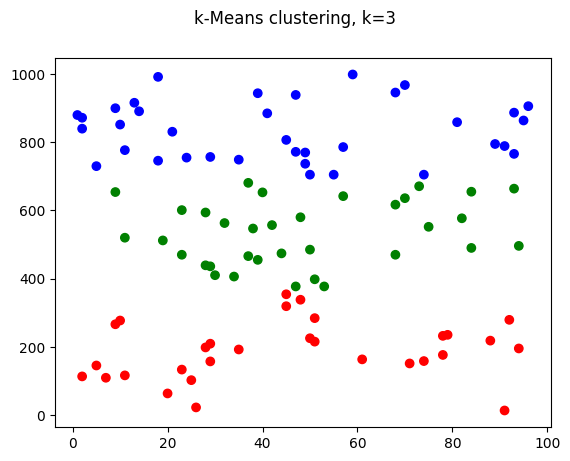

In [61]:
# k = 4일때의 결과
from sklearn import cluster

data = np.column_stack((X, Y))
K=3
model = cluster.KMeans(n_clusters=K, n_init=10)
model.fit(data)
labels = model.predict(data)
colors = np.array(['red', 'green', 'blue', 'magenta'])
plt.suptitle('k-Means clustering, k={}'.format(K))
plt.scatter(data[:, 0], data[:, 1], color=colors[labels])

**위에서 보듯이 군집화가 안되어서 정규화를 해 주어야 한다.**


## 데이타 정규화

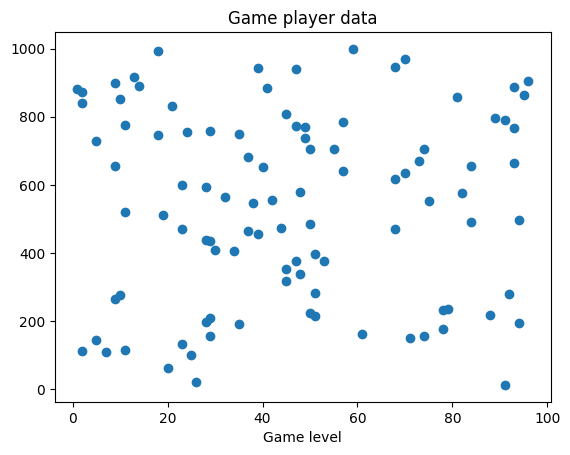

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


game_usage = pd.read_csv('./game_usage.csv')
X = game_usage['time spent']
Y = game_usage['game level']

# 으뜸 게임사의 게임 이용자 분석: 산포도 그래프
plt.title("Game player data")
plt.xlabel('Time spent')
plt.xlabel('Game level')
plt.scatter(X, Y)
plt.show()

**스케일링**

In [ ]:
# 최대, 최소값 스케일러
from sklearn.preprocessing import MinMaxScaler
gamer_data=np.column_stack((X,Y))
scaler = MinMaxScaler() #스캐너임
scaler.fit(gamer_data)
n_data = scaler.transform(gamer_data) #변환해줌. 게임데이타를 스케일을 거쳐서 만듦
n_data[:, 0].mean(), n_data[:, 1].mean()

(np.float64(0.4731578947368421), np.float64(0.5324949290060852))

In [66]:
n_data[:, 0].min(), n_data[:, 0].max()

(np.float64(0.0), np.float64(1.0))

In [67]:
n_data[:, 1].min(), n_data[:, 1].max()

(np.float64(0.0), np.float64(1.0))

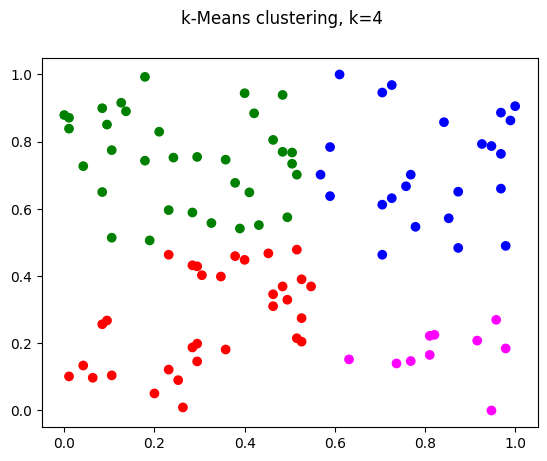

In [ ]:
def kmeans_predict_plot(X, k):
    model = cluster.KMeans(n_clusters=k, n_init=10)
    model.fit(X)
    labels = model.predict(X)
    colors = np.array(['red', 'green', 'blue', 'magenta'])
    plt.suptitle('k-Means clustering, k={}'.format(k))
    plt.scatter(X[:, 0], X[:, 1], color=colors[labels])
    
kmeans_predict_plot(n_data, k = 4) # 4개의 군집 생성

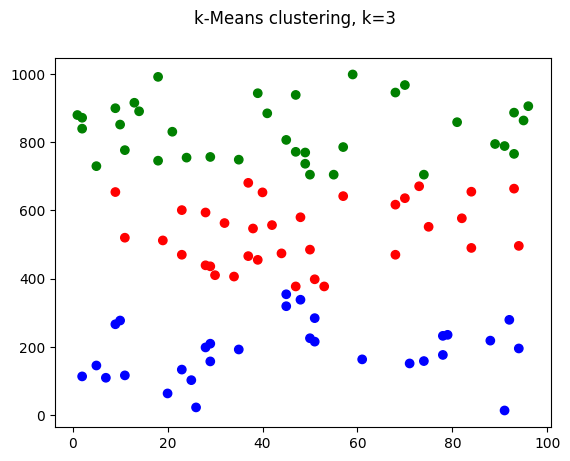

In [ ]:
kmeans_predict_plot(gamer_data, k = 3) # 3개의 군집 생성

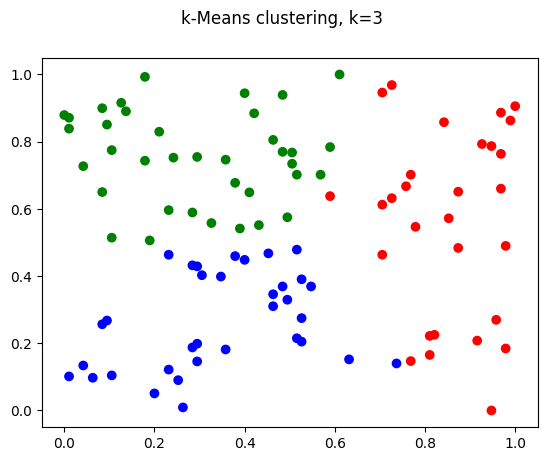

In [71]:
kmeans_predict_plot(n_data, k = 3) # 3개의 군집 생성

## 스케일러 사용 실전 사례: 유방암 데이터셋

In [72]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

# 유방암 데이터세트 읽어오기
cancer=load_breast_cancer()
X_train,X_test,y_train,y_test = train_test_split(cancer.data, cancer.target,random_state=0)
# 학습 데이터 및 테스트 데이터 shape 출력
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
score = knn.score(X_test, y_test)
print(f"스케일러 사용하지 않은 k-NN 정확도: {score:.2f}")

(426, 30) (143, 30) (426,) (143,)
스케일러 사용하지 않은 k-NN 정확도: 0.92


In [73]:
# 최대, 최소값 스케일러
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn.fit(X_train_scaled, y_train) # 조정된 데이터로 kNN 학습

# 스케일 조정된 테스트 세트의 정확도
score = knn.score(X_test_scaled, y_test)
print(f"최대,최소값 스케일러 사용 후 k-NN 정확도: {score:.2f}")

최대,최소값 스케일러 사용 후 k-NN 정확도: 0.95


In [74]:
# 표준 스케일러를 적용하자
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn.fit(X_train_scaled, y_train) # 조정된 데이터로 kNN 학습

# 스케일 조정된 테스트 세트의 정확도
score = knn.score(X_test_scaled, y_test)
print(f"표준 스케일러 사용 후 k-NN 정확도: {score:.2f}")

표준 스케일러 사용 후 k-NN 정확도: 0.94


In [75]:
print(cancer)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30)), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,

In [76]:
print(cancer.data.shape)

(569, 30)


In [77]:
print(cancer.target.shape)

(569,)


In [78]:
print(cancer.data[:10])

[[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
  1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
  6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
  1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
  4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 1.326e+03 8.474e-02 7.864e-02 8.690e-02
  7.017e-02 1.812e-01 5.667e-02 5.435e-01 7.339e-01 3.398e+00 7.408e+01
  5.225e-03 1.308e-02 1.860e-02 1.340e-02 1.389e-02 3.532e-03 2.499e+01
  2.341e+01 1.588e+02 1.956e+03 1.238e-01 1.866e-01 2.416e-01 1.860e-01
  2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 1.203e+03 1.096e-01 1.599e-01 1.974e-01
  1.279e-01 2.069e-01 5.999e-02 7.456e-01 7.869e-01 4.585e+00 9.403e+01
  6.150e-03 4.006e-02 3.832e-02 2.058e-02 2.250e-02 4.571e-03 2.357e+01
  2.553e+01 1.525e+02 1.709e+03 1.444e-01 4.245e-01 4.504e-01 2.430e-01
  3.613e-01 8.758e-02]
 [1.142e+01 2.038e+01 7.758e+01 3.861e+02 1.425e-01 2.839e-01 2.414

In [79]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [80]:
knn.fit(X_train_scaled, y_train) # 조정된 데이터로 kNN 학습

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [81]:
# 스케일 조정된 테스트 세트의 정확도
score = knn.score(X_test_scaled, y_test)
print(f"표준 스케일러 사용 후 k-NN 정확도: {score:.2f}")

표준 스케일러 사용 후 k-NN 정확도: 0.95


### 이번엔 스탠다드 스케일로 직접 해보자


In [82]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

# 유방암 데이터세트 읽어오기
cancer=load_breast_cancer()
X_train,X_test,y_train,y_test = train_test_split(cancer.data, cancer.target,random_state=0)

# 표준 스케일러를 적용하자
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn.fit(X_train_scaled, y_train) # 조정된 데이터로 kNN 학습

# 스케일 조정된 테스트 세트의 정확도
score = knn.score(X_test_scaled, y_test)
print(f"표준 스케일러 사용 후 k-NN 정확도: {score:.2f}")

표준 스케일러 사용 후 k-NN 정확도: 0.94


## 붓꽃이다. 정답은 3개인줄 알고 있는데?


In [83]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

iris = load_iris()

all_features = ['sepal length', 'sepal width', 'petal length', 'petal width']
iris_df = pd.DataFrame(iris.data, columns=all_features)
iris_df.head()

,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


**정답표 찾기**

In [87]:
print(iris.target)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [86]:
# 꽃잎의 길이(petal length)와 너비(petal width) 특성만을 사용
feature_names = ['petal length', 'petal width']
feature = iris_df[feature_names]
feature.head(3)

,petal length,petal width
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2


In [89]:
km_model = KMeans(n_clusters=3, n_init=10)
km_model.fit(feature)

print(km_model.labels_)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 1 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 1 1 2 1 1 1 1
 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1
 1 1]


**군집 중심**

In [ ]:
print('세 군집의 중심 좌표')
print('첫 번째 군집:', km_model.cluster_centers_[0])
print('두 번째 군집:', km_model.cluster_centers_[1])
print('세 번째 군집:', km_model.cluster_centers_[2])

In [90]:
feature_names = ['petal length', 'petal width']
feature = iris_df[feature_names]

km_model = KMeans(n_clusters=3, n_init=10)
km_model.fit(feature)

pred = km_model.predict(feature)
predict = pd.DataFrame(pred, columns=['cluster'])
print(predict.head())

   cluster
0        1
1        1
2        1
3        1
4        1


In [91]:
df = pd.concat([feature, predict], axis = 1)
print(df.head())

   petal length  petal width  cluster
0           1.4          0.2        1
1           1.4          0.2        1
2           1.3          0.2        1
3           1.5          0.2        1
4           1.4          0.2        1


In [93]:
centers = pd.DataFrame(km_model.cluster_centers_, columns=feature_names)
print(centers.head())

   petal length  petal width
0      4.269231     1.342308
1      1.462000     0.246000
2      5.595833     2.037500


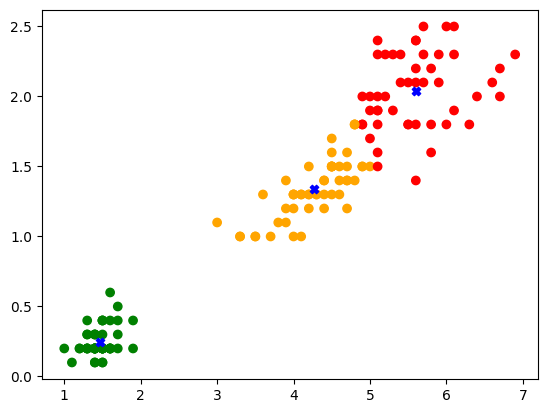

In [94]:
import matplotlib.colors as mcolors

center_x = centers['petal length']  # 클러스터의 중심 x
center_y = centers['petal width']   # 클러스터의 중심 x
colors = ['orange', 'green', 'red'] # 클러스터의 색상

plt.scatter(df['petal length'], df['petal width'],
           c=df['cluster'], cmap = mcolors.ListedColormap(colors))
plt.scatter(center_x, center_y, marker='X', c='b')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score ## 2개의 feature를 가지고 해서 정답률이 낮다.
accuracy_score(km_model.labels_, iris.target)

0.30666666666666664

## 4개모두 사용해보자

In [ ]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

iris = load_iris()

all_features = ['sepal length', 'sepal width', 'petal length', 'petal width']
iris_df = pd.DataFrame(iris.data, columns=all_features)
iris_df.head()

# 꽃잎의 길이(petal length)와 너비(petal width) 특성만을 사용
feature = iris_df[all_features]
feature.head(3)

km_model = KMeans(n_clusters=3, n_init=10)
km_model.fit(feature)

print(km_model.labels_)
print('세 군집의 중심 좌표')
print('첫 번째 군집:', km_model.cluster_centers_[0])
print('두 번째 군집:', km_model.cluster_centers_[1])
print('세 번째 군집:', km_model.cluster_centers_[2])

##만들어보자.
